In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [5]:
df = pd.read_csv(r'C:\Users\ariam\Downloads\Ecommerce Customers (1)', sep=None, engine='python')

In [6]:
df.to_csv(r'C:\Users\ariam\Downloads\converted.csv', index=False)

In [7]:
# Display first 5 rows of the dataset
print(df.head())
# Show dataset structure and data types
print(df.info())
# Show statistical summary of numeric columns
print(df.describe())

                           Email  \
0      mstephenson@fernandez.com   
1              hduke@hotmail.com   
2               pallen@yahoo.com   
3        riverarebecca@gmail.com   
4  mstephens@davidson-herman.com   

                                             Address            Avatar  \
0       835 Frank Tunnel\nWrightmouth, MI 82180-9605            Violet   
1     4547 Archer Common\nDiazchester, CA 06566-8576         DarkGreen   
2  24645 Valerie Unions Suite 582\nCobbborough, D...            Bisque   
3   1414 David Throughway\nPort Jason, OH 22070-1220       SaddleBrown   
4  14023 Rodriguez Passage\nPort Jacobville, PR 3...  MediumAquaMarine   

   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    

In [8]:
# Remove nonnumeric columns that are not useful for training
df = df.drop(['Email', 'Address', 'Avatar'], axis=1)

In [10]:
# Define features (X) and target (y)
X = df[['Avg. Session Length',
        'Time on App',
        'Time on Website',
        'Length of Membership']]


y = df['Yearly Amount Spent']

In [11]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=101
)

In [12]:

# Create Linear Regression model
model = LinearRegression()

# Training the model 
model.fit(X_train, y_train)

LinearRegression()

In [16]:
# Print the intercept of the linear regression model
print(model.intercept_)

# Create a DataFrame to show feature coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

# Display coefficients
coeff_df

-1045.1152168245737


,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


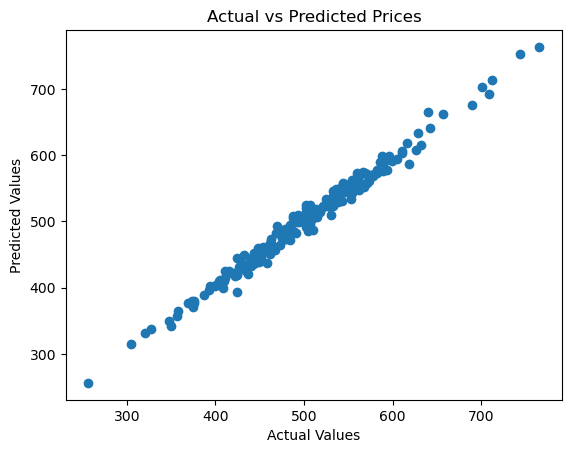

In [18]:
# Make predictions using the trained model
predictions = model.predict(X_test)

# Scatter plot: Actual vs Predicted values (Model Evaluation)
plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Prices")
plt.show()